In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'torch', 'torchvision']
imports = {'pillow': 'PIL'}
pinned = {}
fallbacks = {'torch': 'torch==2.11.0', 'torchvision': 'torchvision==0.26.0'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'torch.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Mixture of Experts

Every model in this chapter so far spends its parameters and its compute
in lockstep: a token flowing through the GPT of that section
multiplies against every weight the model owns, so a model with twice
the parameters charges every token twice the floating-point operations.
The scaling laws that close this chapter will say that parameters are
precisely what we want more of, and the census of
that section says where they would go, since the
feed-forward network already holds two thirds of every block. A
*mixture of experts* (MoE) breaks the lockstep at exactly that spot:
keep $E$ copies of the FFN (the *experts*) and let a small learned
*router* send each token to only $k$ of them. Parameters now scale
with $E$ while per-token compute scales with $k$, and the two dials
turn independently. The idea is old (a committee of specialist
networks under a gating network dates to
@Jacobs.Jordan.Nowlan.ea.1991, sparse routing at scale to
@Shazeer.Mirhoseini.Maziarz.ea.2017), but it is having its
decade: Mixtral, DeepSeek-V3, Qwen3, and gpt-oss all ship it
[@Jiang.Sablayrolles.Roux.ea.2024; @Liu.Feng.Xue.ea.2024; @Yang.Li.Yang.ea.2025; @OpenAI.2025].
This section does the accounting that makes the idea attractive, builds
the layer, meets the failure mode that nearly killed it — routing
collapse — and repairs it twice, once with an auxiliary loss and once
without. We close by swapping the FFN of our GPT for a mixture and
measuring what the extra parameters buy.

In [1]:
%matplotlib inline
from d2l import torch as d2l
import torch
from torch import nn
from torch.nn import functional as F

## Conditional Computation

The bet behind MoE is that a language model's FFN parameters do not all
need to fire on every token. Predicting the next token after "the
integral of" and after "Act I, Scene" exercise different knowledge; a
dense FFN pays for both everywhere, a routed one lets each token consult
the specialists it needs. What makes the bet so attractive is the
asymmetry of the two costs. Stored parameters are cheap: they sit in
memory (or on other devices) and idle experts charge no FLOPs per token.
Compute is the expensive, per-token resource. An MoE layer holds
$E$ experts' parameters but each token pays the FLOPs of $k$, so — at
roughly 2 forward FLOPs per active parameter per token — the model's
capacity and its serving cost decouple.

The arithmetic deserves to be computed rather than asserted, and it is
short enough to check against the published configurations of two
deployed models: Mixtral 8x7B, with 8 full-width experts of which each
token activates 2 [@Jiang.Sablayrolles.Roux.ea.2024], and
DeepSeek-V3, with 256 narrow experts per layer of which each token
activates 8, plus one always-on shared expert
[@Liu.Feng.Xue.ea.2024]. Each expert is a SwiGLU FFN — three
$d \times \textrm{width}$ matrices (that section) —
and the router adds a $d \times E$ matrix per layer. The first row is
the configuration this section trains at the end.

In [2]:
def moe_accounting(name, d, width, num_experts, num_active, num_layers,
                   shared=0, unit=1e9):
    per_expert = 3 * d * width          # SwiGLU: three matrices
    store = num_layers * (num_experts + shared) * per_expert
    active = num_layers * ((num_active + shared) * per_expert
                           + d * num_experts)      # + the router
    tag = 'B' if unit == 1e9 else 'M'
    print(f'{name:>12}: {store/unit:6.1f}{tag} in experts, '
          f'{active/unit:5.1f}{tag} active per token, '
          f'ratio {store/active:4.1f}x')
    return store, active

moe_accounting('ours', 256, 683, 8, 1, 4, unit=1e6)
store, active = moe_accounting('Mixtral 8x7B', 4096, 14336, 8, 2, 32)
attn = 32 * (2 * 4096 * 4096 + 2 * 4096 * 1024)  # GQA: 32 Q, 8 KV heads
emb = 2 * 32000 * 4096                           # embedding + output head
print(f'     with attention and embeddings: {(store+attn+emb)/1e9:.1f}B '
      f'total, {(active+attn+emb)/1e9:.1f}B active')
moe_accounting('DeepSeek-V3', 7168, 2048, 256, 8, 58, shared=1)

        ours:   16.8M in experts,   2.1M active per token, ratio  8.0x
Mixtral 8x7B:   45.1B in experts,  11.3B active per token, ratio  4.0x
     with attention and embeddings: 46.7B total, 12.9B active
 DeepSeek-V3:  656.5B in experts,  23.1B active per token, ratio 28.4x


(656463101952, 23095410688)

For Mixtral, adding the non-expert parameters — grouped-query attention
(that section) and untied embeddings — reproduces the model
card exactly: 46.7B parameters stored, 12.9B active per token. The name
"8x7B" suggests eight times the cost of a 7B model; the accounting says
a token pays for less than two-sevenths of what it could read from.
DeepSeek-V3 pushes the same lever much harder: its 58 expert layers
store about 656B of the model's 671B parameters, yet a token activates
only 23B of them, a 28-fold gap between capacity and per-token compute
(the model card's 37B "active" adds attention, embeddings, and the three
dense layers that our expert-only census leaves out). Our toy
configuration keeps Mixtral's eight-expert layout but routes top-1
rather than top-2, so its 8x store-to-active ratio is twice as sparse
as Mixtral's 4x.

Two caveats before we cash in. First, over any real batch *training*
still touches nearly every expert: gradients flow to whichever experts
the batch's tokens visited, and the whole store must live in accelerator
memory (in practice sharded across
devices, with tokens shipped to their experts and back — the systems
half of MoE, which belongs to a systems chapter). Second, the accounting
assumed the router spreads tokens evenly. Nothing so far makes that
true, and most of this section is about what happens when it is false.

## A Mixture-of-Experts Layer

The layer replaces the FFN, and only the FFN. Attention still
communicates between positions as before; normalization and the
residual stream are untouched. Given a token's vector
$\mathbf{x} \in \mathbb{R}^d$, a linear router scores the $E$ experts,
the top $k$ scores pick the experts, and their outputs are combined,
weighted by the router's own probabilities:

$$
\mathrm{MoE}(\mathbf{x}) = \sum_{i \in \mathcal{E}_k(\mathbf{x})} p_i(\mathbf{x})\, \mathrm{FFN}_i(\mathbf{x}),
\qquad
\mathbf{p}(\mathbf{x}) = \mathrm{softmax}(\mathbf{W}_r \mathbf{x}),
$$

where $\mathcal{E}_k(\mathbf{x})$ is the set of $k$ largest entries of
$\mathbf{p}(\mathbf{x})$. This is *token-choice* routing: each token
independently chooses its experts, so two adjacent tokens in the same
sentence may consult entirely different parameters. Keeping the raw
probability $p_i$ as the mixture weight (rather than renormalizing over
the selected $k$) follows the Switch transformer
[@fedus2022switch], and it is why the router can learn at all: the
selection itself, an argmax, has no gradient, but the *weight* on each
chosen expert does. If expert $i$'s output helps, the loss's gradient
raises $p_i$ and the router routes to it more eagerly — a point worth
dwelling on, and the subject of the first exercise.
the figure shows one token's pass through the layer.

![A mixture-of-experts layer. The router scores all experts for each token; the top-$k$ (here one) expert runs and its output is weighted by the router probability. Unselected experts hold parameters but perform no computation for this token.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-transformers-moe.svg)

One disclosure about the implementation below: it computes
*every* expert on *every* token and multiplies by a gate that is zero
for the unselected ones. The mathematics of the equation is
exact, but the FLOPs savings of the accounting cell is deliberately not
realized — at our scale the dense computation is simpler and plenty
fast. Production systems realize the savings with scatter/gather
kernels: tokens are physically regrouped per expert, each expert runs
one dense batch of its own tokens, and fixed per-expert buffer sizes
(the *capacity factor*, another exercise) keep the shapes static. The
teaching implementation preserves the semantics; the accounting carries
the economics.

In [3]:
class MoELayer(nn.Module):
    """Mixture-of-experts FFN: a token-choice top-k router over E experts."""
    def __init__(self, num_hiddens, num_experts, num_active):
        super().__init__()
        self.num_experts, self.num_active = num_experts, num_active
        self.router = nn.Linear(num_hiddens, num_experts, bias=False)
        self.experts = nn.ModuleList([d2l.FeedForward(num_hiddens)
                                      for _ in range(num_experts)])
        self.register_buffer('expert_bias', torch.zeros(num_experts))
        self.register_buffer('usage', torch.zeros(num_experts))

    def forward(self, X):
        probs = F.softmax(self.router(X), -1)             # (B, T, E)
        scores = probs + self.expert_bias                 # selection only
        idx = scores.topk(self.num_active, -1).indices    # (B, T, k)
        mask = torch.zeros_like(probs).scatter(-1, idx, 1.0)
        gates = probs * mask                              # weight = p_i
        Y = torch.stack([e(X) for e in self.experts], -1)  # (B, T, d, E)
        out = (Y * gates.unsqueeze(-2)).sum(-1)
        frac = mask.sum((0, 1)) / mask.sum()              # realized load
        self.usage += mask.sum((0, 1)).detach()
        self.aux_loss = self.num_experts * (frac * probs.mean((0, 1))).sum()
        return out

The experts are the `d2l.FeedForward` of
that section, unchanged. Two buffers ride along for
later: `expert_bias` enters the top-$k$ *selection* but never the
mixture weights, and `usage` counts routed tokens — both sit idle until
the balancing experiments below. The layer also reports `aux_loss`, a
balance score whose meaning the next section derives; nothing uses it
yet. Since `MoELayer` maps $(n, d)$ to $(n, d)$ like any FFN, it drops
into `d2l.TransformerBlock` through the `ffn_factory` seam that
that section built and that section already
used for attention:

In [4]:
torch.manual_seed(0)
moe = MoELayer(256, num_experts=8, num_active=2)
X = torch.randn(4, 100, 256)
d2l.check_shape(moe(X), X.shape)
blk = d2l.TransformerBlock(256, num_heads=8,
                           ffn_factory=lambda: MoELayer(256, 8, 2))
d2l.check_shape(blk(X), X.shape)
count = lambda m: sum(p.numel() for p in m.parameters())
expert = count(moe.experts[0])
print(f'router {count(moe.router)}, per expert {expert}, total '
      f'{count(moe)}, active '
      f'{count(moe) - (moe.num_experts - moe.num_active) * expert}')
print('usage at initialization: '
      + ' '.join(f'{u:.2f}' for u in moe.usage / moe.usage.sum()))

router 2048, per expert 524544, total 4198400, active 1051136
usage at initialization: 0.13 0.14 0.15 0.10 0.12 0.12 0.11 0.13


At initialization the picture is as benign as the accounting assumed: a
random router spreads random tokens nearly evenly across the eight
experts. The interesting question is whether training keeps it that way.

## Routing Collapse and Load Balancing

It does not.

### The Rich Get Richer

Follow the feedback loop. Early in training some expert — by pure
initialization luck — is slightly better than its peers on the tokens it
happens to receive. The loss gradient rewards it twice: its parameters
improve on those tokens, *and* the router's gradient raises its
selection probability, because weighting a helpful expert more heavily
lowers the loss. More tokens mean more gradient signal, which means a
better expert, which attracts more tokens. The experts that lose the
early rounds see ever fewer tokens, learn ever more slowly, and their
router scores sink. The stable end state is *routing collapse*: a couple
of experts serve everything while the rest ride along as dead weight,
the capacity we listed as the whole point of the architecture unused.
@Shazeer.Mirhoseini.Maziarz.ea.2017 describe exactly this
self-reinforcing imbalance, and every practical MoE since has shipped
some countermeasure. We will see the collapse live in a moment; first,
the two countermeasures we will test against it.

### An Auxiliary Balancing Loss

The classic repair adds a differentiable penalty for imbalance to the
training loss. For a batch, let $f_i$ be the fraction of routed tokens
that expert $i$ received (a count — no gradient flows through it), and
let $\bar{p}_i$ be the router's mean probability for expert $i$. The
Switch transformer's loss [@fedus2022switch], descended from
GShard's [@Lepikhin.Lee.Xu.ea.2021], is their correlation:

$$
\mathcal{L}_{\mathrm{balance}} = E \sum_{i=1}^{E} f_i\, \bar{p}_i,
$$

added to the language-modeling loss with a small weight $\alpha$ (0.01
in the Switch paper and below). When routing is uniform,
$f_i = \bar{p}_i = 1/E$ and the loss is exactly $1$; concentrating
tokens on few experts makes $f$ and $\bar{p}$ peak together and the
correlation grow. Its gradient (through $\bar{p}$ only) pushes
probability away from overloaded experts *for every token, whatever the
token needs* — and that is the cost. The balancing gradient is added to
the language-modeling gradient at every step, and the two disagree
whenever genuinely popular knowledge deserves a busy expert. Tune
$\alpha$ too high and routing quality degrades; too low and the
imbalance persists. This interference is documented rather than
hypothetical [@Wang.Gao.Zeng.ea.2024], and it motivated the second
repair.

### Balancing Without a Loss

The `expert_bias` buffer in our layer implements the auxiliary-loss-free
scheme of @Wang.Gao.Zeng.ea.2024, the one DeepSeek-V3 trains
with [@Liu.Feng.Xue.ea.2024]. Selection — and only selection — sees
a per-expert bias:

$$
\mathcal{E}_k(\mathbf{x}) = \operatorname{argtop}_k \big(p_i(\mathbf{x}) + b_i\big),
\qquad
b_i \leftarrow b_i + u\, \mathrm{sign}(\bar{f} - f_i),
$$

where $\bar{f} = 1/E$ is the ideal load and $u$ is a small update speed.
This is not gradient descent; it is a thermostat. After each step, every
overloaded expert's bias ticks down and every underloaded expert's ticks
up, making the starved experts slightly easier to *select* — but because
$b_i$ never enters the mixture weight $p_i$, the loss the model
optimizes contains no balancing term at all, so there is no gradient
interference to tune away. The controller steers where tokens go; the
gradients remain purely about predicting text. One simplification to
note: DeepSeek-V3's router scores experts with per-expert sigmoids and
restricts each token's choices to a few expert groups (which also limits
cross-device traffic); our layer keeps the softmax router and changes
only the selection bias — the mechanism @Wang.Gao.Zeng.ea.2024
isolate.

### Three Runs, One Budget

Both repairs slot into an ordinary training loop. The trainer below is
`d2l.train_lm` (that section) plus the two mechanisms, each
switched by one argument: `aux_weight` adds
$\alpha \sum \mathcal{L}_{\mathrm{balance}}$ over the model's MoE
layers, and `bias_rate` runs the thermostat of the equation
after each optimizer step. To build the model we take `d2l.GPT`
unchanged and replace each block's FFN, the same
swap-after-construction move that section used to install
grouped-query attention:

In [5]:
def moe_gpt(vocab_size, num_hiddens, num_blks, num_experts, num_active,
            num_heads=4):
    """A d2l.GPT whose blocks' FFNs are replaced by MoE layers."""
    model = d2l.GPT(vocab_size, num_hiddens=num_hiddens,
                    num_heads=num_heads, num_blks=num_blks)
    for blk in model.blks:
        blk.ffn = MoELayer(num_hiddens, num_experts, num_active)
    return model

def train_moe_lm(model, data, optimizer, num_steps, aux_weight=0.0,
                 bias_rate=0.0):
    """d2l.train_lm plus the two balancing mechanisms."""
    device = d2l.try_gpu()
    model.to(device)
    layers = [blk.ffn for blk in model.blks
              if isinstance(blk.ffn, MoELayer)]
    losses, step = [], 0
    while step < num_steps:
        for X, Y in data.train_dataloader():
            X, Y = X.to(device), Y.to(device)
            logits = model(X)
            ce = F.cross_entropy(logits.reshape(-1, logits.shape[-1]),
                                 Y.reshape(-1))
            loss = ce
            if aux_weight:
                loss = loss + aux_weight * sum(l.aux_loss for l in layers)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            if bias_rate:               # the thermostat: no gradients
                with torch.no_grad():
                    for l in layers:
                        frac = l.usage / l.usage.sum()
                        l.expert_bias += bias_rate * torch.sign(
                            1 / l.num_experts - frac)
                        l.usage.zero_()
            losses.append(ce.item())
            step += 1
            if step >= num_steps:
                return losses

Two measurement helpers: validation loss as in that section, and
each layer's expert-usage distribution over a fixed set of validation
batches.

In [6]:
def val_loss(model, data):
    device = d2l.try_gpu()
    model.to(device).eval()
    with torch.no_grad():
        losses = [F.cross_entropy(
            model(X.to(device)).flatten(0, 1), Y.to(device).flatten())
            for X, Y in data.val_dataloader()]
    model.train()
    return sum(l.item() for l in losses) / len(losses)

def usage_fractions(model, data, num_batches=10):
    """Per-layer expert usage over a fixed set of validation batches."""
    device = d2l.try_gpu()
    layers = [blk.ffn for blk in model.blks
              if isinstance(blk.ffn, MoELayer)]
    for l in layers:
        l.usage.zero_()
    model.to(device).eval()
    with torch.no_grad():
        for i, (X, _) in enumerate(data.val_dataloader()):
            if i >= num_batches:
                break
            model(X.to(device))
    model.train()
    return torch.stack([l.usage / l.usage.sum() for l in layers]).cpu()

Now the experiment. One small model — two blocks of width 128, eight
experts per block, one active per token (the Switch configuration,
where the feedback loop bites hardest) — trained three times from the
same initialization on the character-level Time Machine for the same
800 steps. The only difference between the runs is the balancing: none,
the auxiliary loss at $\alpha = 0.01$, or the bias thermostat at
$u = 0.01$.

In [7]:
data = d2l.TimeMachine(batch_size=64, num_steps=128, tokenization='char',
                       num_train=100000, num_val=3000)
results = {}
for name, aux_weight, bias_rate in (('no balancing', 0.0, 0.0),
                                    ('auxiliary loss', 0.01, 0.0),
                                    ('bias', 0.0, 0.01)):
    torch.manual_seed(0)
    model = moe_gpt(len(data.vocab), num_hiddens=128, num_blks=2,
                    num_experts=8, num_active=1)
    losses = train_moe_lm(
        model, data, torch.optim.AdamW(model.parameters(), lr=1e-3,
                                       weight_decay=0.0),
        800, aux_weight, bias_rate)
    results[name] = usage_fractions(model, data)
    print(f'{name:>14}: training loss {sum(losses[-100:])/100:.2f}, '
          f'experts under 2% usage: {int((results[name] < 0.02).sum())} '
          'of 16')

  no balancing: training loss 0.72, experts under 2% usage: 5 of 16


auxiliary loss: training loss 0.66, experts under 2% usage: 0 of 16


          bias: training loss 0.54, experts under 2% usage: 0 of 16


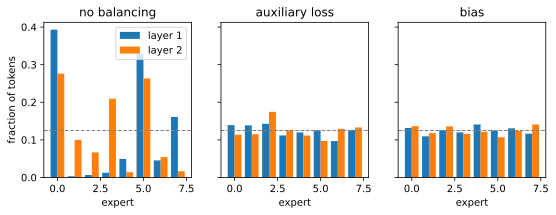

In [8]:
d2l.use_svg_display()
fig, axes = d2l.plt.subplots(1, 3, figsize=(9, 2.8), sharey=True)
x = torch.arange(8)
for ax, (name, u) in zip(axes, results.items()):
    ax.bar(x - 0.2, u[0], 0.4, label='layer 1')
    ax.bar(x + 0.2, u[1], 0.4, label='layer 2')
    ax.axhline(1 / 8, color='gray', ls='--', lw=1)
    ax.set_xlabel('expert')
    ax.set_title(name)
axes[0].set_ylabel('fraction of tokens')
axes[0].legend()

The left panel is the collapse, caught red-handed. Without balancing, a
handful of experts absorb most of the traffic and several fall below 2%
usage — dead weight exactly as the feedback-loop argument predicted.
How hard the collapse bites varies with the seed (rerunning, we have
seen anywhere from two dead experts to a layer served entirely by a
single one), but it appears in every run of every seed in both
frameworks. The other two panels show both repairs doing their job: the
auxiliary loss and the thermostat flatten usage onto the dashed uniform
line, with no expert dead and none dominant, and they do it equally
well.

The training-loss column tells the quieter half of the story, and it
needs the more careful reading. A collapsed model trains with only a
fraction of its FFN parameters participating, and the runs bear the
prediction out directionally: in every seed we tried, in both
frameworks, the unbalanced run finished above both balanced ones. But
the margin is anywhere from a few hundredths to a few tenths of a nat
depending on the seed — the same order as the run-to-run spread of any
single variant — so take the direction from the loss column and the
conviction from the histograms. Between the two repairs our experiment
offers no verdict at all: their loss ranges overlap across seeds, and
the summary our data supports is that both recover the lost capacity
equally well here. The reason DeepSeek prefers the bias is the interference
argument above, and that is a frontier-scale, small-margin effect
[@Wang.Gao.Zeng.ea.2024], far below our noise floor; we say so
rather than pretend our 800 steps could adjudicate it.

## Fine-Grained and Shared Experts

Mixtral's experts are full-width FFNs, eight complete copies with two
active: big specialists, coarsely chosen. The DeepSeek line of models
argues for slicing the same budget thinner
[@Dai.Deng.Zhao.ea.2024]. Hold the stored parameters and the
active parameters fixed, but make each expert several times narrower
and multiply the count and $k$ accordingly: instead of choosing 2 of 8
experts, choose 8 of 64 quarter-width ones. The active-parameter
accounting is identical; what changes is *composability*. With $k$
narrow experts a token assembles its FFN from
$\binom{64}{8} \approx 4 \times 10^{9}$ combinations rather than
$\binom{8}{2} = 28$, so specializations can mix and match — one slice
for chemistry vocabulary and another for parsing nested clauses,
combined on demand rather than fused into one wide monolith.

The second DeepSeek refinement removes a redundancy that fine-grained
routing exposes. Every token, whatever its topic, needs some common
processing, and with purely routed experts each one must dedicate some
of its width to those shared functions. So DeepSeek adds one *shared
expert* that every token passes through unconditionally, alongside its
$k$ routed choices: the common knowledge lives once, in the always-on
path, and the routed experts spend their entire width on what actually
distinguishes them. Neither refinement changes a line of our layer's
logic — narrower experts change a constructor argument, and the shared
expert is one more FFN added outside the router's jurisdiction (the
final exercise builds it). We do not race granularities here: at our
two-block scale the difference sits inside seed noise, and the design's
justification is a frontier-scale ablation
[@Dai.Deng.Zhao.ea.2024], not a claim our 180 KB corpus can test.
What the deployed configurations converged on, however, is worth
reading as data:

<!-- tbl-caption:Routed-expert configurations of deployed MoE language models. -->

| Model | Experts per layer | Active $k$ | Expert width / $d$ | Shared expert |
|---|---|---|---|---|
| Mixtral 8x7B [@Jiang.Sablayrolles.Roux.ea.2024] | 8 | 2 | 3.5 | none |
| DeepSeek-V3 [@Liu.Feng.Xue.ea.2024] | 256 | 8 | 0.29 | 1 |
| Qwen3-235B [@Yang.Li.Yang.ea.2025] | 128 | 8 | 0.38 | none |
| gpt-oss-120b [@OpenAI.2025] | 128 | 4 | 1.0 | none |

The trend since Mixtral runs toward many narrow experts with moderate
$k$; the shared expert has advocates (DeepSeek since V2
[@DeepSeek-AI.2024]) and abstainers (Qwen3 dropped it after using
one in its previous generation). As with the block architecture in
that section, the field agrees on the axis and still
argues about one notch on the dial.

## A Mixture-of-Experts GPT

Time to collect. We train two models on the same data for the same 600
steps: the dense `d2l.GPT` of that section at width 256 with four
blocks, and the same model with every FFN replaced by a mixture of
eight experts, one active, balanced by the thermostat. Because the
active expert is a full-width `FeedForward`, the two models do the
same per-token compute and hold the same *active* parameters up to the
router's rounding error; the MoE simply holds seven spare experts per
block. Since that section showed this corpus drives models into
memorization within a few hundred steps, we compare the *best*
validation loss over the budget, as that section did.

In [9]:
count = lambda m: sum(p.numel() for p in m.parameters())
for name in ('dense', 'MoE'):
    torch.manual_seed(0)
    if name == 'dense':
        model = d2l.GPT(len(data.vocab), num_hiddens=256, num_heads=8,
                        num_blks=4)
    else:
        model = moe_gpt(len(data.vocab), num_hiddens=256, num_blks=4,
                        num_experts=8, num_active=1, num_heads=8)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3,
                                  weight_decay=0.0)
    best = float('inf')
    for chunk in range(6):
        if name == 'dense':
            losses = d2l.train_lm(model, data, optimizer, 100)
        else:
            losses = train_moe_lm(model, data, optimizer, 100,
                                  bias_rate=0.01)
        best = min(best, val_loss(model, data))
    active = count(model)
    if name == 'MoE':
        active -= sum((blk.ffn.num_experts - blk.ffn.num_active)
                      * count(blk.ffn.experts[0]) for blk in model.blks)
    print(f'{name:>5}: {count(model)/1e6:5.2f}M parameters '
          f'({active/1e6:.2f}M active), best validation {best:.2f}, '
          f'final training loss {sum(losses[-50:])/50:.2f}')

dense:  3.16M parameters (3.16M active), best validation 1.51, final training loss 0.21


  MoE: 17.85M parameters (3.16M active), best validation 1.52, final training loss 0.19


The mixture holds between five and six times the parameters of the
dense baseline at the same active count, and the comparison comes out
the way our data budget says it must. Best validation loss is
indistinguishable: both land near 1.5, within the couple-of-hundredths
spread that reseeding produces. The training loss ends slightly lower
for the MoE, consistently across seeds and frameworks: the spare
experts are real capacity, and on a corpus this small, real capacity
spends itself on memorizing faster (that section). That is the
claim our scale supports: matched on active compute, the MoE trains
comparably while carrying several times the parameters, and nothing
more. The regime where the extra capacity pays on *validation* is the
one the accounting cell described: corpora that outweigh any dense
model you could afford to serve, where MoEs reach a given loss at a
fraction of the training FLOPs of dense models
[@fedus2022switch; @Dai.Deng.Zhao.ea.2024] and dominate the
deployed frontier. What our small-scale run demonstrates is the
mechanism working end to end — routed capacity added, balance held by
a controller, quality preserved at fixed per-token cost — which is
precisely the part that does transfer across five orders of magnitude.

## Summary

A mixture of experts replaces the transformer block's FFN with $E$
parallel FFNs and a linear router that sends each token to the top $k$
of them, weighted by routing probability: parameters scale with $E$,
per-token FLOPs with $k$. The accounting is the argument, computed
from published configurations: Mixtral 8x7B stores 46.7B parameters
and activates 12.9B per token, and DeepSeek-V3 stores 28 times what a
token touches. Left alone, routing collapses: winners attract
gradient, gradient makes winners, and a few experts end up serving
everything while the rest die. The auxiliary balancing loss penalizes
the correlation between load and routing probability at the price of a
gradient that competes with the language-modeling objective; the
auxiliary-loss-free bias steers only the top-$k$ selection through a
gradient-free control loop. In our triptych both flatten usage
completely and both beat the collapsed run, while differing from each
other by less than seed noise. Modern designs slice capacity thinner
(many narrow experts, sometimes one shared always-on expert), and our
GPT accepts the whole apparatus through a swapped FFN: at matched
active parameters, the mixture trains comparably to dense while
holding several times the weights — the trade that has made MoE a
major scaling strategy at the frontier.

## Exercises

1. The top-$k$ selection is an argmax and has no gradient, yet the
   router trains. Write the layer's output for a single token as
   $\mathbf{y} = \sum_{i \in \mathcal{E}_k} p_i\, \mathrm{FFN}_i(\mathbf{x})$
   and derive
   $\partial \mathcal{L} / \partial z_j$ for the router logits
   $\mathbf{z} = \mathbf{W}_r \mathbf{x}$, treating $\mathcal{E}_k$ as
   constant. Which experts receive routing gradient? Now suppose the
   gate weights are renormalized over the selected set,
   $g_i = p_i / \sum_{j \in \mathcal{E}_k} p_j$, as Mixtral does. Show
   that for $k = 1$ the router's gradient vanishes identically — and
   explain why Mixtral's $k = 2$ escapes this trap.
2. Production MoE systems give each expert a fixed token buffer of
   capacity $c \cdot N k / E$ for a batch of $N$ tokens (the *capacity
   factor* $c$); tokens routed to a full expert are *dropped* — they
   skip the FFN and ride the residual stream unchanged
   [@Lepikhin.Lee.Xu.ea.2021; @fedus2022switch]. Explain why static
   buffers are needed at all (consider batching across devices), what
   happens to dropped tokens' representations, and why a *batch-level*
   balance objective matters for hardware efficiency even if the model
   could tolerate statistical imbalance. What does $c = 1$ force the
   router to be? What does large $c$ cost?
3. Rerun the triptych with `num_active=2`. Does the unbalanced run
   still collapse, and as hard? Explain the difference using the
   feedback-loop argument: how does a second active expert change the
   gradient received by the runners-up?
4. Sweep the auxiliary-loss weight $\alpha$ over
   $\{0, 10^{-3}, 10^{-2}, 10^{-1}, 1\}$. Plot final training loss and
   the number of dead experts against $\alpha$. Where does balancing
   stop improving and interference start hurting? Then sweep the bias
   update speed $u$ over the same grid: which failure mode appears at
   large $u$, and why is it gentler than large $\alpha$?
5. Our layer computes every expert densely and masks. Implement the
   gathered alternative in PyTorch: for each expert, `torch.where` the
   indices of its assigned tokens, run the expert on just those rows,
   and scatter the results back. Verify it matches the dense layer's
   output, then measure at what expert count the gathered version
   becomes faster on your hardware.
6. Add a DeepSeek-style shared expert: one additional `FeedForward`
   applied to every token, its output added to the routed mixture
   (no gate). Compare against the plain layer at matched *active*
   parameters (shrink $k$ or the widths accordingly) on the triptych
   task. Does the shared expert change how quickly the routed experts
   specialize — measure usage entropy over training?